In [1]:

# DATA LOADING AND RANDOM TRAINING/VALIDATION/TEST PARTITIONING
import os
import numpy as np
import torch
import time
import pandas as pd

from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler


# Evaluation matrics
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from lifelines.utils import concordance_index

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import Ridge
import xgboost as xgb



RANDOM_STATE = 42
BATCH_SIZE = 16

SPLIT_FILE = "data/processed_features/fixed_split_indices.npz"

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: mps


In [ ]:

# CONFIGURATION
FEATURE_DIR = "data/processed/features"

SPLIT_FILE = os.path.join(
    FEATURE_DIR,
    "fixed_split_indices.npz",
)

RANDOM_STATE = 42



# LOAD FEATURES
ligand_features = np.load(
    os.path.join(FEATURE_DIR, "ligand_features.npy"),
    mmap_mode="r",
)

protein_esm_features = np.load(
    os.path.join(FEATURE_DIR, "protein_esm_features.npy"),
    mmap_mode="r",
)

protein_token_features = np.load(
    os.path.join(FEATURE_DIR, "protein_token_features.npy"),
    mmap_mode="r",
)

ligand_index = np.load(
    os.path.join(FEATURE_DIR, "ligand_index.npy")
)

protein_index = np.load(
    os.path.join(FEATURE_DIR, "protein_index.npy")
)

y = np.load(
    os.path.join(FEATURE_DIR, "y.npy")
)



# CREATE / LOAD FIXED SPLIT
if os.path.exists(SPLIT_FILE):

    print("Loading existing split...")

    split = np.load(SPLIT_FILE)

    train_idx = split["train_idx"]
    val_idx = split["val_idx"]
    test_idx = split["test_idx"]

else:

    print("Creating fixed split...")

    indices = np.arange(len(y))

    train_val_idx, test_idx = train_test_split(
        indices,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    np.savez(
        SPLIT_FILE,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )



# MACHINE LEARNING DATA
def get_ml_data():

    X_train = np.concatenate(
        [
            ligand_features[ligand_index[train_idx]],
            protein_esm_features[protein_index[train_idx]],
        ],
        axis=1,
    )

    X_val = np.concatenate(
        [
            ligand_features[ligand_index[val_idx]],
            protein_esm_features[protein_index[val_idx]],
        ],
        axis=1,
    )

    X_test = np.concatenate(
        [
            ligand_features[ligand_index[test_idx]],
            protein_esm_features[protein_index[test_idx]],
        ],
        axis=1,
    )

    y_train = y[train_idx]
    y_val = y[val_idx]
    y_test = y[test_idx]

    return (
        X_train,
        X_val,
        X_test,

        y_train,
        y_val,
        y_test,
    )

Loading existing split...


In [52]:
(X_train, X_val, X_test, y_train, y_val, y_test) = get_ml_data()

In [ ]:


# Utility Functions
def predict_in_batches(
    model,
    X,
    batch_size=BATCH_SIZE
):
    """
    Predict in smaller batches to reduce peak memory usage.
    """

    predictions = []

    for start_index in range(0, len(X), batch_size):
        end_index = min(
            start_index + batch_size,
            len(X)
        )

        batch_predictions = model.predict(
            X[start_index:end_index]
        )

        predictions.append(
            np.asarray(
                batch_predictions,
                dtype=np.float32
            ).ravel()
        )

    return np.concatenate(predictions)


In [54]:

def train_and_evaluate(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    evaluator
):
    """
    Train and evaluate a standard scikit-learn-compatible model.
    """

    print(f"\nTraining {model_name}...")

    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    predictions = predict_in_batches(
        model,
        X_test
    )
    
    inference_time = time.perf_counter() - start_time

    evaluator.evaluate(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        train_time=train_time,
        inference_time=inference_time
    )

    return model

In [ ]:
from lifelines.utils import concordance_index


# Output paths
RESULTS_FILE = "artifacts/metrics/baseline_model_results.csv"
PLOT_DIR = "artifacts/plots"

os.makedirs(PLOT_DIR, exist_ok=True)



# Evaluation
class ModelEvaluator:

    def __init__(self):
        self.results = []


    
    # Evaluate a single model
    def evaluate(
        self,
        model_name,
        y_true,
        y_pred,
        train_time,
        inference_time
    ):
        """
        Calculate regression metrics and store the results.
        """

        y_true = np.asarray(y_true).ravel()
        y_pred = np.asarray(y_pred).ravel()

        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        c_index = concordance_index(y_true, y_pred)

        # Pearson correlation is undefined for constant arrays
        if (
            len(y_true) > 1
            and np.std(y_true) > 0
            and np.std(y_pred) > 0
        ):
            pearson_corr, _ = pearsonr(y_true, y_pred)
        else:
            pearson_corr = 0.0
        
        

        result = {
            "Model": model_name,
            "MSE": float(mse),
            "RMSE": float(rmse),
            "MAE": float(mae),
            "R2_Score": float(r2),
            "Pearson_Correlation": float(pearson_corr),
            "Train_Time_sec": float(train_time),
            "Inference_Time_sec": float(inference_time),
            "Concordance_Index": float(c_index)
        }

        self.results.append(result)

        print(f"\n--- {model_name} Evaluation ---")

        print(
            f"MSE: {mse:.4f} | "
            f"RMSE: {rmse:.4f} | "
            f"MAE: {mae:.4f} | "
            f"Concordance Index: {c_index:.4f}"
        )

        print(
            f"R²: {r2:.4f} | "
            f"Pearson: {pearson_corr:.4f}"
        )

        print(
            f"Train time: {train_time:.2f}s | "
            f"Inference time: {inference_time:.4f}s"
        )


    
    # Results dataframe
    def get_results_dataframe(self):
        """
        Return model results ordered by RMSE.
        Lower RMSE indicates better performance.
        """

        if not self.results:
            return pd.DataFrame()

        return (
            pd.DataFrame(self.results)
            .sort_values(by="RMSE", ascending=True)
            .reset_index(drop=True)
        )


    
    # Print summary table
    def print_summary(self):

        results_df = self.get_results_dataframe()

        if results_df.empty:
            print("No model results are available.")
            return

        print("\n" + "=" * 120)
        print("BASELINE MODEL PERFORMANCE COMPARISON")
        print("=" * 120)

        display_df = results_df.copy()

        numeric_columns = display_df.select_dtypes(
            include=[np.number]
        ).columns

        display_df[numeric_columns] = (
            display_df[numeric_columns].round(4)
        )

        print(display_df.to_string(index=False))


    
    # Save results to CSV
    def save_to_csv(self, filepath=RESULTS_FILE):
        """
        Save all accumulated model results to CSV.
        """

        results_df = self.get_results_dataframe()

        if results_df.empty:
            print("No results to save.")
            return

        output_directory = os.path.dirname(filepath)

        if output_directory:
            os.makedirs(output_directory, exist_ok=True)

        results_df.to_csv(filepath, index=False)

        print(
            f"\nResults successfully saved to: {filepath}"
        )


    
    # Plot 1: Error metrics
    def plot_error_metrics(
        self,
        save_path=None
    ):
        """
        Compare MSE, RMSE and MAE across baseline models.
        Lower values indicate better performance.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        metrics = ["MSE", "RMSE", "MAE"]

        x = np.arange(len(df))
        width = 0.25

        fig, ax = plt.subplots(figsize=(12, 6))

        for i, metric in enumerate(metrics):

            bars = ax.bar(
                x + (i - 1) * width,
                df[metric],
                width,
                label=metric
            )

            ax.bar_label(
                bars,
                fmt="%.3f",
                padding=3,
                fontsize=8
            )

        ax.set_xlabel("Model")
        ax.set_ylabel("Error")
        ax.set_title(
            "Baseline Model Error Metrics Comparison"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            df["Model"],
            rotation=20,
            ha="right"
        )

        ax.legend()

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_error_metrics.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Plot 2: R²
    def plot_r2(
        self,
        save_path=None
    ):
        """
        Plot R² score for each baseline model.
        Higher values indicate better performance.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["R2_Score"]
        )

        ax.bar_label(
            bars,
            fmt="%.3f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("R² Score")
        ax.set_title(
            "Baseline Model R² Score Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_r2_scores.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Plot 3: Pearson correlation
    def plot_pearson(
        self,
        save_path=None
    ):
        """
        Plot Pearson correlation.
        Higher values indicate stronger linear agreement.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Pearson_Correlation"]
        )

        ax.bar_label(
            bars,
            fmt="%.3f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Pearson Correlation")
        ax.set_title(
            "Baseline Model Pearson Correlation Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_pearson_correlation.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Plot 4: Training time
    def plot_training_time(
        self,
        save_path=None
    ):
        """
        Compare model training times.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Train_Time_sec"]
        )

        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Training Time (seconds)")
        ax.set_title(
            "Baseline Model Training Time Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_training_time.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Plot 5: Inference time
    def plot_inference_time(
        self,
        save_path=None
    ):
        """
        Compare model inference times.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for plotting.")
            return

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            df["Model"],
            df["Inference_Time_sec"]
        )

        ax.bar_label(
            bars,
            fmt="%.4f",
            padding=3
        )

        ax.set_xlabel("Model")
        ax.set_ylabel("Inference Time (seconds)")
        ax.set_title(
            "Baseline Model Inference Time Comparison"
        )

        plt.xticks(
            rotation=20,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_inference_time.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Generate comparison table as image
    def plot_results_table(
        self,
        save_path=None
    ):
        """
        Generate a model comparison table and save as an image.
        """

        df = self.get_results_dataframe()

        if df.empty:
            print("No results available for table.")
            return

        display_df = df.copy()

        # Shorter column names for dissertation table
        display_df = display_df.rename(
            columns={
                "R2_Score": "R²",
                "Pearson_Correlation": "Pearson",
                "Train_Time_sec": "Train Time (s)",
                "Inference_Time_sec": "Inference Time (s)"
            }
        )

        # Round values
        columns_4dp = [
            "MSE",
            "RMSE",
            "MAE",
            "R²",
            "Pearson",
            "Inference Time (s)"
        ]

        for col in columns_4dp:
            display_df[col] = display_df[col].map(
                lambda x: f"{x:.4f}"
            )

        display_df["Train Time (s)"] = (
            display_df["Train Time (s)"]
            .map(lambda x: f"{x:.2f}")
        )

        fig_height = max(
            2.5,
            0.6 * len(display_df) + 1.5
        )

        fig, ax = plt.subplots(
            figsize=(15, fig_height)
        )

        ax.axis("off")

        table = ax.table(
            cellText=display_df.values,
            colLabels=display_df.columns,
            cellLoc="center",
            loc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.6)

        ax.set_title(
            "Baseline Model Performance Comparison",
            fontsize=14,
            pad=20
        )

        plt.tight_layout()

        if save_path is None:
            save_path = os.path.join(
                PLOT_DIR,
                "baseline_results_table.png"
            )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(f"Saved: {save_path}")


    
    # Generate everything
    def generate_report(self):
        """
        Print table, save CSV, and generate all baseline plots.
        """

        self.print_summary()

        self.save_to_csv()

        self.plot_error_metrics()

        self.plot_r2()

        self.plot_pearson()

        self.plot_training_time()

        self.plot_inference_time()

        self.plot_results_table()

In [56]:
evaluator = ModelEvaluator()

In [57]:

assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

assert X_train.shape[1] == X_val.shape[1]
assert X_train.shape[1] == X_test.shape[1]

assert np.isfinite(y_train).all()
assert np.isfinite(y_val).all()
assert np.isfinite(y_test).all()

print("\nDataset partitions")
print("-" * 40)
print(f"Train      : {len(y_train):,}")
print(f"Validation : {len(y_val):,}")
print(f"Test       : {len(y_test):,}")
print(f"Features   : {X_train.shape[1]:,}")

number_of_features = X_train.shape[1]

# Keep a copy of the test target for later verification
fixed_y_test = np.asarray(y_test).ravel().copy()

# Store predictions for later plotting/statistical testing
prediction_results = {
    "Experimental_pKi": fixed_y_test
}



Dataset partitions
----------------------------------------
Train      : 298,715
Validation : 74,679
Test       : 93,349
Features   : 1,344


In [58]:

print("1. Mean Baseline")

dummy_model = DummyRegressor(
    strategy="mean"
)

dummy_model = train_and_evaluate(
    model=dummy_model,
    model_name="Mean Baseline",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=fixed_y_test,
    evaluator=evaluator
)

dummy_predictions = dummy_model.predict(
    X_test
)

prediction_results[
    "Mean_Baseline"
] = np.asarray(dummy_predictions).ravel()

1. Mean Baseline

Training Mean Baseline...

--- Mean Baseline Evaluation ---
MSE: 2.2776 | RMSE: 1.5092 | MAE: 1.2073 | Concordance Index: 0.5000
R²: -0.0000 | Pearson: 0.0000
Train time: 0.00s | Inference time: 0.0191s


In [59]:
print("2. Ridge Regression")
ridge_alphas = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

best_ridge_alpha = None
best_ridge_rmse = np.inf

print("\nSelecting Ridge alpha using validation set...")

for alpha in ridge_alphas:

    ridge_candidate = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "ridge",
            Ridge(
                alpha=alpha,
                solver="lsqr",
                max_iter=10_000,
                tol=1e-4
            )
        )
    ])

    ridge_candidate.fit(
        X_train,
        y_train
    )

    val_predictions = ridge_candidate.predict(
        X_val
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_predictions
        )
    )

    print(
        f"alpha={alpha:<7} "
        f"Validation RMSE={val_rmse:.4f}"
    )

    if val_rmse < best_ridge_rmse:

        best_ridge_rmse = val_rmse
        best_ridge_alpha = alpha


print(
    f"\nBest Ridge alpha: "
    f"{best_ridge_alpha}"
)

print(
    f"Best validation RMSE: "
    f"{best_ridge_rmse:.4f}"
)

ridge_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(
            alpha=best_ridge_alpha,
            solver="lsqr",
            max_iter=10_000,
            tol=1e-4
        )
    )
])

ridge_pipeline = train_and_evaluate(
    model=ridge_pipeline,
    model_name="Ridge Regression",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=fixed_y_test,
    evaluator=evaluator
)

ridge_predictions = ridge_pipeline.predict(
    X_test
)

prediction_results[
    "Ridge_Regression"
] = np.asarray(ridge_predictions).ravel()

2. Ridge Regression

Selecting Ridge alpha using validation set...
alpha=0.01    Validation RMSE=1.2452
alpha=0.1     Validation RMSE=1.2452
alpha=1.0     Validation RMSE=1.2452
alpha=10.0    Validation RMSE=1.2452
alpha=100.0   Validation RMSE=1.2452

Best Ridge alpha: 10.0
Best validation RMSE: 1.2452

Training Ridge Regression...

--- Ridge Regression Evaluation ---
MSE: 1.5656 | RMSE: 1.2512 | MAE: 0.9919 | Concordance Index: 0.6832
R²: 0.3126 | Pearson: 0.5591
Train time: 10.09s | Inference time: 0.5787s


In [60]:
rf_candidates = [
    {
        "max_depth": 12,
        "min_samples_leaf": 3,
        "max_features": 0.20
    },
    {
        "max_depth": 16,
        "min_samples_leaf": 3,
        "max_features": 0.20
    },
    {
        "max_depth": 20,
        "min_samples_leaf": 3,
        "max_features": 0.20
    }
]

best_rf_params = None
best_rf_rmse = np.inf

print(
    "\nSelecting Random Forest parameters "
    "using validation set..."
)


for params in rf_candidates:

    rf_candidate = RandomForestRegressor(
        n_estimators=50,

        max_depth=params["max_depth"],

        min_samples_split=8,

        min_samples_leaf=params["min_samples_leaf"],

        max_features=params["max_features"],

        max_samples=0.80,

        bootstrap=True,

        n_jobs=-1,

        random_state=RANDOM_STATE
    )


    rf_candidate.fit(
        X_train,
        y_train
    )


    val_predictions = rf_candidate.predict(
        X_val
    )


    val_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_predictions
        )
    )


    print(
        f"{params} "
        f"-> RMSE={val_rmse:.4f}"
    )


    if val_rmse < best_rf_rmse:
        best_rf_rmse = val_rmse
        best_rf_params = params


print(
    "\nBest RF parameters:",
    best_rf_params
)

print(
    f"Best validation RMSE: "
    f"{best_rf_rmse:.4f}"
)



Selecting Random Forest parameters using validation set...
{'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 0.2} -> RMSE=1.1337
{'max_depth': 16, 'min_samples_leaf': 3, 'max_features': 0.2} -> RMSE=1.0206
{'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 0.2} -> RMSE=0.9302

Best RF parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 0.2}
Best validation RMSE: 0.9302


In [ ]:
print("3. Random Forest")

import gc



# FREE MEMORY FROM PARAMETER SELECTION
if "rf_candidate" in globals():
    del rf_candidate

if "val_predictions" in globals():
    del val_predictions

gc.collect()



# TRAIN FINAL RANDOM FOREST
random_forest_model = RandomForestRegressor(

    n_estimators=100,

    max_depth=20,

    min_samples_split=8,

    min_samples_leaf=3,

    max_features=0.2,

    max_samples=0.80,

    bootstrap=True,

    # Avoid excessive memory usage
    n_jobs=2,

    random_state=RANDOM_STATE
)


random_forest_model = train_and_evaluate(

    model=random_forest_model,

    model_name="Random Forest",

    X_train=X_train,

    y_train=y_train,

    X_test=X_test,

    y_test=fixed_y_test,

    evaluator=evaluator
)



# STORE TEST PREDICTIONS

rf_predictions = random_forest_model.predict(
    X_test
)

prediction_results[
    "Random_Forest"
] = np.asarray(
    rf_predictions
).ravel()

3. Random Forest

Training Random Forest...

--- Random Forest Evaluation ---
MSE: 0.8729 | RMSE: 0.9343 | MAE: 0.7241 | Concordance Index: 0.7952
R²: 0.6167 | Pearson: 0.7952
Train time: 326.01s | Inference time: 73.2206s


In [62]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import xgboost as xgb
import numpy as np

In [63]:
X_train = np.asarray(
    X_train,
    dtype=np.float32
)

X_val = np.asarray(
    X_val,
    dtype=np.float32
)

X_test = np.asarray(
    X_test,
    dtype=np.float32
)

y_train = np.asarray(
    y_train,
    dtype=np.float32
).ravel()

y_val = np.asarray(
    y_val,
    dtype=np.float32
).ravel()

In [64]:
print(
    "X_train memory:",
    X_train.nbytes / 1024**3,
    "GB"
)

print(
    "X_val memory:",
    X_val.nbytes / 1024**3,
    "GB"
)

X_train memory: 1.495603322982788 GB
X_val memory: 0.3739020824432373 GB


In [65]:

model = xgb.XGBRegressor(
    objective="reg:squarederror",

    n_estimators=1000,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=5,

    subsample=0.80,

    colsample_bytree=0.70,

    reg_alpha=0.05,

    reg_lambda=1.0,

    tree_method="hist",

    max_bin=256,

    early_stopping_rounds=50,

    eval_metric="rmse",

    n_jobs=-1,

    random_state=RANDOM_STATE
)

start_time = time.perf_counter()
model.fit(
    X_train,
    y_train,
     eval_set=[
            (
                X_val,
                y_val
            )
        ],
)

xgb_train_time = (
        time.perf_counter()
        - start_time
    )

start_time = time.perf_counter()

xgb_predictions = predict_in_batches(
    model,
    X_test
)


xgb_inference_time = (
    time.perf_counter()
    - start_time
)

evaluator.evaluate(

    model_name="XGBoost",

    y_true=fixed_y_test,

    y_pred=xgb_predictions,

    train_time=xgb_train_time,

    inference_time=xgb_inference_time
)


prediction_results[
    "XGBoost"
] = np.asarray(
    xgb_predictions
).ravel()


if (
    hasattr(
        model,
        "best_iteration"
    )
    and model.best_iteration
    is not None
):

    print(
        f"Best XGBoost iteration: "
        f"{model.best_iteration}"
    )


[0]	validation_0-rmse:1.49735
[1]	validation_0-rmse:1.48969
[2]	validation_0-rmse:1.48273
[3]	validation_0-rmse:1.47530
[4]	validation_0-rmse:1.46811
[5]	validation_0-rmse:1.46192
[6]	validation_0-rmse:1.45494
[7]	validation_0-rmse:1.44876
[8]	validation_0-rmse:1.44220
[9]	validation_0-rmse:1.43588
[10]	validation_0-rmse:1.42980
[11]	validation_0-rmse:1.42412
[12]	validation_0-rmse:1.41863
[13]	validation_0-rmse:1.41327
[14]	validation_0-rmse:1.40809
[15]	validation_0-rmse:1.40334
[16]	validation_0-rmse:1.39897
[17]	validation_0-rmse:1.39477
[18]	validation_0-rmse:1.39019
[19]	validation_0-rmse:1.38618
[20]	validation_0-rmse:1.38241
[21]	validation_0-rmse:1.37858
[22]	validation_0-rmse:1.37488
[23]	validation_0-rmse:1.37071
[24]	validation_0-rmse:1.36737
[25]	validation_0-rmse:1.36353
[26]	validation_0-rmse:1.35965
[27]	validation_0-rmse:1.35575
[28]	validation_0-rmse:1.35271
[29]	validation_0-rmse:1.34983
[30]	validation_0-rmse:1.34668
[31]	validation_0-rmse:1.34364
[32]	validation_0-

In [66]:
print("5. Approximate RBF Kernel Ridge")

svm_sample_size = min(
    20_000,
    len(X_train)
)


random_generator = np.random.default_rng(
    RANDOM_STATE
)


kernel_indices = random_generator.choice(

    len(X_train),

    size=svm_sample_size,

    replace=False
)


X_train_kernel = X_train[
    kernel_indices
]

y_train_kernel = y_train[
    kernel_indices
]

5. Approximate RBF Kernel Ridge


In [ ]:

base_gamma = (
    1.0
    / number_of_features
)


gamma_candidates = [

    base_gamma * 0.1,

    base_gamma,

    base_gamma * 10
]


best_gamma = None
best_kernel_rmse = np.inf


print(
    "\nSelecting RBF gamma using validation set..."
)


for gamma in gamma_candidates:

    kernel_candidate = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "nystroem",
            Nystroem(
                kernel="rbf",
                gamma=gamma,
                n_components=1000,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),
        (
            "ridge",
            Ridge(
                alpha=1.0,
                solver="lsqr",
                max_iter=5000,
                tol=1e-3
            )
        )
    ])


    kernel_candidate.fit(
        X_train_kernel,
        y_train_kernel
    )


    val_predictions = kernel_candidate.predict(
        X_val
    )


    val_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_predictions
        )
    )


    print(
        f"gamma={gamma:.8f} "
        f"Validation RMSE={val_rmse:.4f}"
    )


    if val_rmse < best_kernel_rmse:

        best_kernel_rmse = val_rmse
        best_gamma = gamma


print(
    f"\nBest gamma: {best_gamma:.8f}"
)

print(
    f"Best validation RMSE: "
    f"{best_kernel_rmse:.4f}"
)



# Final Approximate Kernel Ridge
kernel_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "nystroem",
        Nystroem(
            kernel="rbf",
            gamma=best_gamma,
            n_components=1_000,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    (
        "ridge",
        Ridge(
            alpha=1.0,
            solver="lsqr",
            max_iter=5_000,
            tol=1e-3
        )
    )
])


kernel_pipeline = train_and_evaluate(

    model=kernel_pipeline,

    model_name=(
        "Approximate RBF Kernel Ridge"
    ),

    X_train=X_train_kernel,

    y_train=y_train_kernel,

    X_test=X_test,

    y_test=fixed_y_test,

    evaluator=evaluator
)


kernel_predictions = (
    kernel_pipeline.predict(
        X_test
    )
)


prediction_results[
    "Approx_RBF_Kernel_Ridge"
] = np.asarray(
    kernel_predictions
).ravel()


# Release temporary arrays
del X_train_kernel
del y_train_kernel
del kernel_indices



# 6. VERIFY COMMON TEST SET
print("\n" + "=" * 70)
print("TEST-SET CONSISTENCY CHECK")
print("=" * 70)


for model_name, predictions \
        in prediction_results.items():

    if model_name == "Experimental_pKi":
        continue

    assert (
        len(predictions)
        ==
        len(fixed_y_test)
    ), (
        f"{model_name} predictions "
        "do not match test-set size."
    )


    assert np.isfinite(
        predictions
    ).all(), (
        f"{model_name} contains "
        "invalid predictions."
    )


    print(
        f"{model_name:<30} "
        f"{len(predictions):>8,} predictions ✓"
    )


print(
    "\nAll models evaluated on the "
    "same fixed test observations."
)



Selecting RBF gamma using validation set...
gamma=0.00007440 Validation RMSE=1.3074
gamma=0.00074405 Validation RMSE=1.2965
gamma=0.00744048 Validation RMSE=1.4961

Best gamma: 0.00074405
Best validation RMSE: 1.2965

Training Approximate RBF Kernel Ridge...

--- Approximate RBF Kernel Ridge Evaluation ---
MSE: 1.7004 | RMSE: 1.3040 | MAE: 1.0408 | Concordance Index: 0.6612
R²: 0.2534 | Pearson: 0.5055
Train time: 0.54s | Inference time: 85.2263s

TEST-SET CONSISTENCY CHECK
Mean_Baseline                    93,349 predictions ✓
Ridge_Regression                 93,349 predictions ✓
Random_Forest                    93,349 predictions ✓
XGBoost                          93,349 predictions ✓
Approx_RBF_Kernel_Ridge          93,349 predictions ✓

All models evaluated on the same fixed test observations.



Saved predictions to:
results/baseline_test_predictions.csv

BASELINE MODEL PERFORMANCE COMPARISON
                       Model    MSE   RMSE    MAE  R2_Score  Pearson_Correlation  Train_Time_sec  Inference_Time_sec  Concordance_Index
               Random Forest 0.8729 0.9343 0.7241    0.6167               0.7952        326.0134             73.2206             0.7952
                     XGBoost 1.0086 1.0043 0.7859    0.5572               0.7564        623.1099              2.5534             0.7741
            Ridge Regression 1.5656 1.2512 0.9919    0.3126               0.5591         10.0901              0.5787             0.6832
Approximate RBF Kernel Ridge 1.7004 1.3040 1.0408    0.2534               0.5055          0.5416             85.2263             0.6612
               Mean Baseline 2.2776 1.5092 1.2073   -0.0000               0.0000          0.0013              0.0191             0.5000

Results successfully saved to: results/baseline_model_results.csv

BASELINE MODEL P

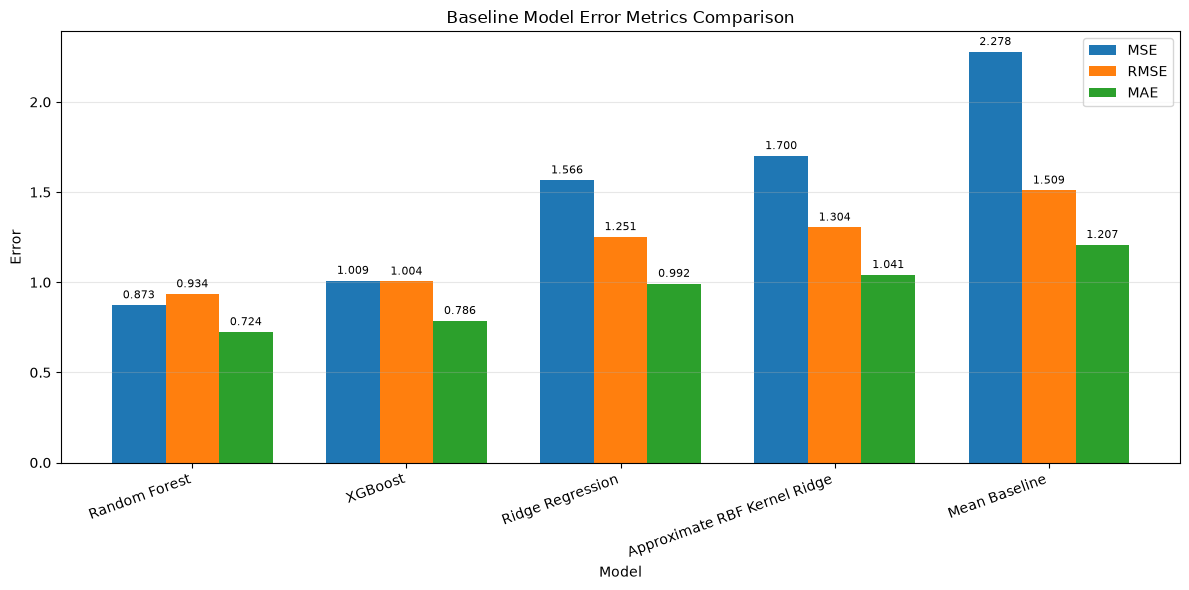

Saved: results/plots/baseline_error_metrics.png


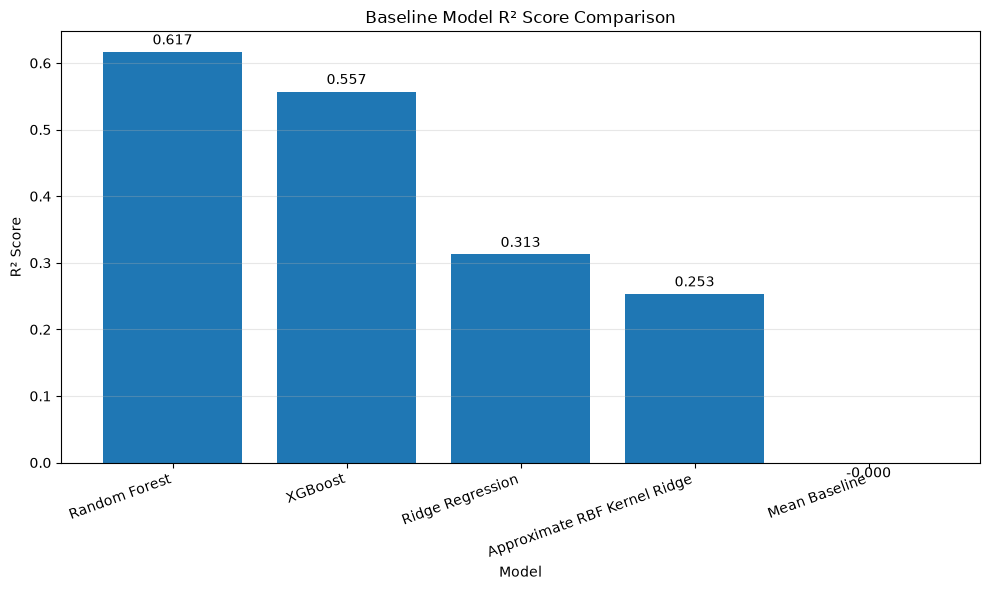

Saved: results/plots/baseline_r2_scores.png


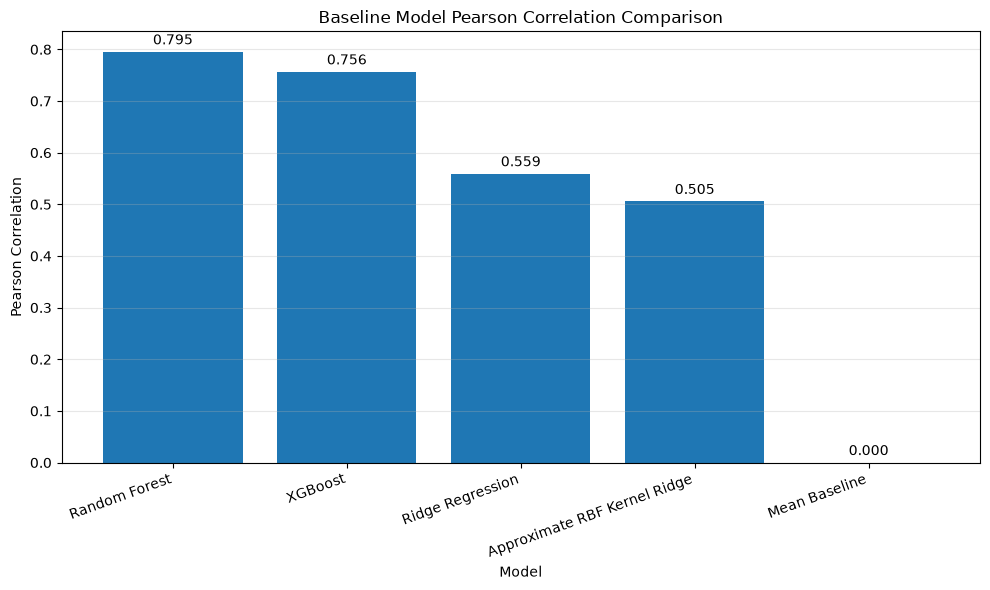

Saved: results/plots/baseline_pearson_correlation.png


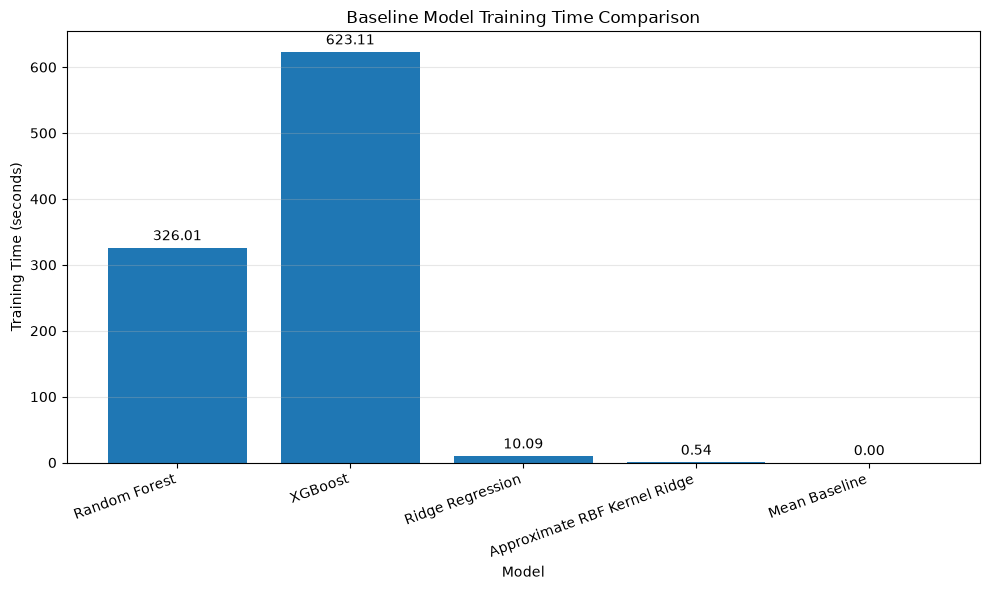

Saved: results/plots/baseline_training_time.png


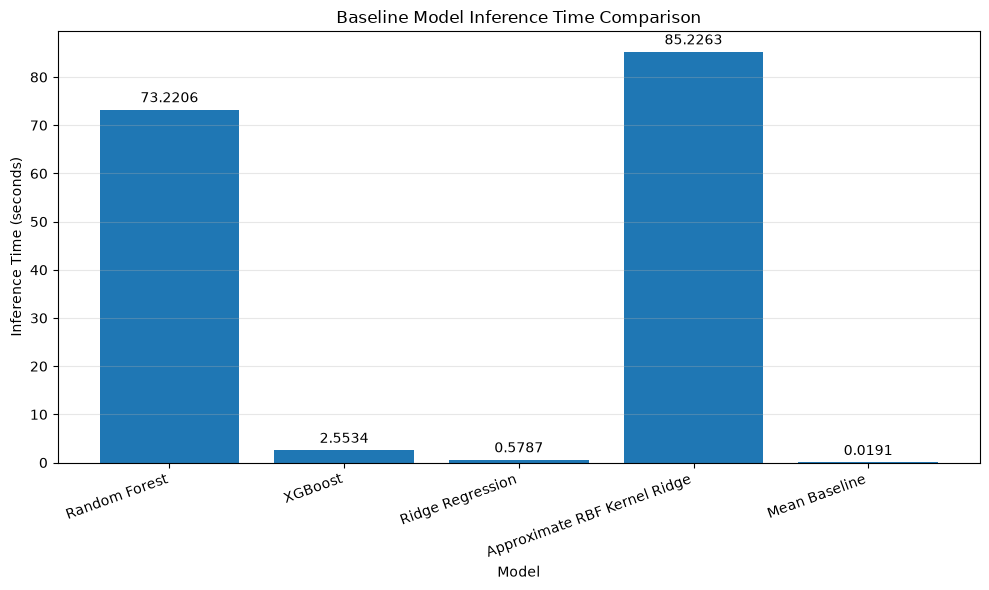

Saved: results/plots/baseline_inference_time.png


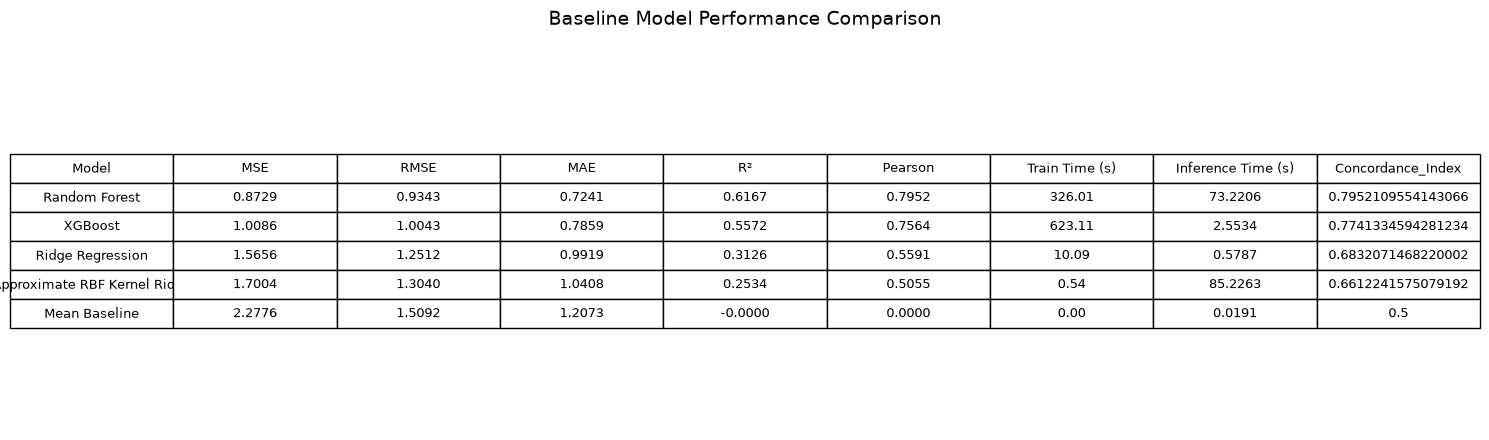

Saved: results/plots/baseline_results_table.png


In [68]:
os.makedirs(
        "results",
        exist_ok=True
    )

predictions_df = pd.DataFrame(
    prediction_results
)


predictions_df.to_csv(

    "results/"
    "baseline_test_predictions.csv",

    index=False
)


print(
    "\nSaved predictions to:"
    "\nresults/"
    "baseline_test_predictions.csv"
)



# 8. FINAL MODEL COMPARISON

evaluator.print_summary()

evaluator.save_to_csv(
    RESULTS_FILE
)

evaluator.generate_report()